# GFO-only benchmarking notebook

This notebook keeps **only the original GFO** and removes the two-group variant.

It expands the comparison framework in two directions:

1. **Continuous optimization benchmarks**, similar to the engineering benchmark section in the Greylag Goose Optimization paper.
2. **Real ML datasets**, where each optimizer tunes model hyperparameters on several datasets.


## Step 1 — Imports

In [1]:
import math
import warnings
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ranksums, friedmanchisquare, rankdata, f_oneway

warnings.filterwarnings("ignore")

## Step 2 — Utilities

In [2]:
RANDOM_SEED = 42

def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)

def clamp(X: np.ndarray, lb: np.ndarray, ub: np.ndarray) -> np.ndarray:
    return np.minimum(np.maximum(X, lb), ub)

def safe_norm(v: np.ndarray, axis: int = -1, keepdims: bool = False, eps: float = 1e-12) -> np.ndarray:
    return np.linalg.norm(v, axis=axis, keepdims=keepdims) + eps

def rand_idx_excluding(n: int, exclude: int, k: int) -> np.ndarray:
    pool = np.array([i for i in range(n) if i != exclude])
    return np.random.choice(pool, size=k, replace=False)

def make_bounds(d: int, lb: float, ub: float) -> Tuple[np.ndarray, np.ndarray]:
    return np.full(d, lb, dtype=float), np.full(d, ub, dtype=float)

## Step 3 — Continuous benchmark functions

This section expands the synthetic benchmark suite beyond the earlier notebook.

In [3]:
# =========================
# Benchmark Functions
# =========================
import numpy as np

def sphere(x: np.ndarray) -> float:
    return float(np.sum(x**2))

def rosenbrock(x: np.ndarray) -> float:
    return float(np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (x[:-1] - 1.0)**2))

def rastrigin(x: np.ndarray) -> float:
    return float(10.0 * len(x) + np.sum(x**2 - 10.0 * np.cos(2.0 * np.pi * x)))

def ackley(x: np.ndarray) -> float:
    a, b, c = 20.0, 0.2, 2.0 * np.pi
    d = len(x)
    s1 = np.sum(x**2)
    s2 = np.sum(np.cos(c * x))
    return float(-a * np.exp(-b * np.sqrt(s1 / d + 1e-12))
                 - np.exp(s2 / d) + a + np.e)

def griewank(x: np.ndarray) -> float:
    d = len(x)
    return float(1.0 + np.sum(x**2) / 4000.0
                 - np.prod(np.cos(x / np.sqrt(np.arange(1, d + 1)))))

def schwefel(x: np.ndarray) -> float:
    d = len(x)
    return float(418.9829 * d - np.sum(x * np.sin(np.sqrt(np.abs(x)))))

def zakharov(x: np.ndarray) -> float:
    i = np.arange(1, len(x) + 1)
    s1 = np.sum(x**2)
    s2 = np.sum(0.5 * i * x)
    return float(s1 + s2**2 + s2**4)

def levy(x: np.ndarray) -> float:
    w = 1 + (x - 1) / 4
    term1 = np.sin(np.pi * w[0])**2
    term3 = (w[-1] - 1)**2 * (1 + np.sin(2 * np.pi * w[-1])**2)
    term2 = np.sum((w[:-1] - 1)**2 *
                   (1 + 10 * np.sin(np.pi * w[:-1] + 1)**2))
    return float(term1 + term2 + term3)

def styblinski_tang(x: np.ndarray) -> float:
    return float(0.5 * np.sum(x**4 - 16*x**2 + 5*x))

def dixon_price(x: np.ndarray) -> float:
    term1 = (x[0] - 1)**2
    i = np.arange(2, len(x) + 1)
    term2 = np.sum(i * (2 * x[1:]**2 - x[:-1])**2)
    return float(term1 + term2)

def michalewicz(x: np.ndarray, m: float = 10) -> float:
    i = np.arange(1, len(x) + 1)
    return float(-np.sum(np.sin(x) *
                         (np.sin(i * x**2 / np.pi))**(2 * m)))

def bent_cigar(x: np.ndarray) -> float:
    return float(x[0]**2 + 1e6 * np.sum(x[1:]**2))

def discus(x: np.ndarray) -> float:
    return float(1e6 * x[0]**2 + np.sum(x[1:]**2))

def sum_squares(x: np.ndarray) -> float:
    i = np.arange(1, len(x) + 1)
    return float(np.sum(i * x**2))

# -------- Additional functions --------

def alpine1(x: np.ndarray) -> float:
    return float(np.sum(np.abs(x * np.sin(x) + 0.1 * x)))

def alpine2(x: np.ndarray) -> float:
    return float(np.prod(np.sqrt(np.abs(x)) * np.sin(x)))

def booth(x: np.ndarray) -> float:
    return float((x[0] + 2*x[1] - 7)**2 + (2*x[0] + x[1] - 5)**2)

def matyas(x: np.ndarray) -> float:
    return float(0.26 * (x[0]**2 + x[1]**2) - 0.48 * x[0] * x[1])

def three_hump_camel(x: np.ndarray) -> float:
    x1, x2 = x[0], x[1]
    return float(2*x1**2 - 1.05*x1**4 + x1**6 / 6 + x1*x2 + x2**2)

def six_hump_camel(x: np.ndarray) -> float:
    x1, x2 = x[0], x[1]
    return float((4 - 2.1*x1**2 + (x1**4)/3)*x1**2 + x1*x2 + (-4 + 4*x2**2)*x2**2)

def beale(x: np.ndarray) -> float:
    x1, x2 = x[0], x[1]
    return float((1.5 - x1 + x1*x2)**2 +
                 (2.25 - x1 + x1*x2**2)**2 +
                 (2.625 - x1 + x1*x2**3)**2)

def goldstein_price(x: np.ndarray) -> float:
    x1, x2 = x[0], x[1]
    term1 = 1 + (x1 + x2 + 1)**2 * (19 - 14*x1 + 3*x1**2 - 14*x2 + 6*x1*x2 + 3*x2**2)
    term2 = 30 + (2*x1 - 3*x2)**2 * (18 - 32*x1 + 12*x1**2 + 48*x2 - 36*x1*x2 + 27*x2**2)
    return float(term1 * term2)

def powell_sum(x: np.ndarray) -> float:
    i = np.arange(1, len(x) + 1)
    return float(np.sum(np.abs(x)**(i + 1)))

def quartic(x: np.ndarray) -> float:
    i = np.arange(1, len(x) + 1)
    return float(np.sum(i * x**4))

def elliptic(x: np.ndarray) -> float:
    d = len(x)
    coeff = 10**6 ** (np.arange(d) / max(d - 1, 1))
    return float(np.sum(coeff * x**2))

def salomon(x: np.ndarray) -> float:
    r = np.sqrt(np.sum(x**2))
    return float(1 - np.cos(2 * np.pi * r) + 0.1 * r)

def xin_she_yang_n2(x: np.ndarray) -> float:
    return float(np.sum(np.abs(x)) * np.exp(-np.sum(np.sin(x**2))))

def xin_she_yang_n4(x: np.ndarray) -> float:
    return float((np.sum(np.sin(x)**2) - np.exp(-np.sum(x**2))) *
                 np.exp(-np.sum(np.sin(np.sqrt(np.abs(x)))**2)))

def trid(x: np.ndarray) -> float:
    return float(np.sum((x - 1)**2) - np.sum(x[1:] * x[:-1]))

def perm_zero_d_beta(x: np.ndarray, beta: float = 10.0) -> float:
    d = len(x)
    total = 0.0
    for i in range(1, d + 1):
        inner = 0.0
        for j in range(1, d + 1):
            inner += ((j**i) + beta) * ((x[j - 1] / j)**i - 1)
        total += inner**2
    return float(total)

def powell(x: np.ndarray) -> float:
    # dimension should be multiple of 4
    d = len(x)
    m = d // 4
    total = 0.0
    for i in range(m):
        x1, x2, x3, x4 = x[4*i:4*i+4]
        total += (x1 + 10*x2)**2
        total += 5*(x3 - x4)**2
        total += (x2 - 2*x3)**4
        total += 10*(x1 - x4)**4
    return float(total)

def rotated_hyper_ellipsoid(x: np.ndarray) -> float:
    return float(np.sum(np.cumsum(x)**2))

# =========================
#  Benchmark Dictionary
# =========================
BENCHMARKS = {
    "Sphere": (sphere, -5.0, 5.0),
    "Rosenbrock": (rosenbrock, -5.0, 10.0),
    "Rastrigin": (rastrigin, -5.12, 5.12),
    "Ackley": (ackley, -32.0, 32.0),
    "Griewank": (griewank, -600.0, 600.0),
    "Schwefel": (schwefel, -500.0, 500.0),
    "Zakharov": (zakharov, -5.0, 10.0),
    "Levy": (levy, -10.0, 10.0),
    "StyblinskiTang": (styblinski_tang, -5.0, 5.0),
    "DixonPrice": (dixon_price, -10.0, 10.0),
    "Michalewicz": (michalewicz, 0.0, np.pi),
    "BentCigar": (bent_cigar, -5.0, 5.0),
    "Discus": (discus, -5.0, 5.0),
    "SumSquares": (sum_squares, -10.0, 10.0),
    "Alpine1": (alpine1, -10.0, 10.0),
    "Alpine2": (alpine2, 0.0, 10.0),
    "Booth": (booth, -10.0, 10.0),                 # 2D
    "Matyas": (matyas, -10.0, 10.0),               # 2D
    "ThreeHumpCamel": (three_hump_camel, -5.0, 5.0),   # 2D
    "SixHumpCamel": (six_hump_camel, -3.0, 3.0),       # 2D
    "Beale": (beale, -4.5, 4.5),                   # 2D
    "GoldsteinPrice": (goldstein_price, -2.0, 2.0),    # 2D
    "PowellSum": (powell_sum, -1.0, 1.0),
    "Quartic": (quartic, -1.28, 1.28),
    "Elliptic": (elliptic, -5.0, 5.0),
    "Salomon": (salomon, -100.0, 100.0),
    "XinSheYangN2": (xin_she_yang_n2, -2*np.pi, 2*np.pi),
    "XinSheYangN4": (xin_she_yang_n4, -10.0, 10.0),
    "Trid": (trid, -100.0, 100.0),
    "PermDBeta": (perm_zero_d_beta, -1.0, 1.0),
    "Powell": (powell, -4.0, 5.0),
    "RotatedHyperEllipsoid": (rotated_hyper_ellipsoid, -65.536, 65.536),
}

## Step 4 — GFO parameters

In [4]:
@dataclass
class GFOParams:
    n_agents: int = 40
    iters: int = 300
    seed: int = 42

    alpha_mass: float = 2.5

    G0: float = 1.3
    gamma_G: float = 1.8

    kappa0: float = 0.10
    gamma_kappa: float = 1.0

    p: float = 2.0
    q: float = 4.0

    R0_max_frac: float = 0.35
    R0_min_frac: float = 0.05

    lam0: float = 0.02
    lam_max: float = 3.2

    delta0: float = 0.90
    gamma_delta: float = 1.8

    smax_frac: float = 0.25
    beta_step: float = 1.8
    step_noise_sigma: float = 0.08

    stagnation_window: int = 12
    boost_iters: int = 8
    boost_G_factor: float = 1.35
    boost_delta_factor: float = 1.10

    k_neighbors: Optional[int] = None

    jump_prob0: float = 0.10
    jump_phase_cutoff: float = 0.55
    protected_elites: int = 5
    restart_frac: float = 0.10

    local_search_start: float = 0.70
    local_sigma0: float = 0.05

    leader_weights: Tuple[float, float, float] = (0.5, 0.3, 0.2)

    levy_prob0: float = 0.18
    levy_phase_cutoff: float = 0.65
    levy_scale: float = 0.12

    elite_refine_count: int = 3
    refine_trials: int = 2

## Step 5 — GFO schedule and field model

In [5]:
def levy_flight(n: int, d: int, beta: float = 1.5) -> np.ndarray:
    sigma_u = (
        math.gamma(1 + beta) * np.sin(np.pi * beta / 2)
        / (math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))
    ) ** (1 / beta)
    u = np.random.randn(n, d) * sigma_u
    v = np.random.randn(n, d)
    step = u / (np.abs(v) ** (1 / beta) + 1e-12)
    return step

def gfo_schedule(t: int, T: int, delta_bar: float, P: GFOParams) -> Dict[str, float]:
    Tm1 = max(T - 1, 1)
    frac = t / Tm1

    Gt = P.G0 * np.exp(-P.gamma_G * frac)
    kappat = P.kappa0 * np.exp(-P.gamma_kappa * frac)
    R0 = (P.R0_max_frac * delta_bar) * (1 - frac) + (P.R0_min_frac * delta_bar)

    lam = P.lam0 + (P.lam_max - P.lam0) * (frac ** 3)

    delta = P.delta0 * np.exp(-2.2 * frac)
    s_base = (P.smax_frac * delta_bar) * ((1 - frac) ** (0.65 * P.beta_step))

    jump_prob = P.jump_prob0 * (1 - frac) if frac < P.jump_phase_cutoff else 0.0
    levy_prob = P.levy_prob0 * (1 - frac) if frac < P.levy_phase_cutoff else 0.0

    step_noise = P.step_noise_sigma * (1 - frac)
    local_sigma = P.local_sigma0 * ((1 - frac) ** 1.5)

    return {
        "frac": frac,
        "G": Gt,
        "kappa": kappat,
        "R0": R0,
        "lam": lam,
        "delta": delta,
        "s_base": s_base,
        "jump_prob": jump_prob,
        "levy_prob": levy_prob,
        "step_noise": step_noise,
        "local_sigma": local_sigma,
    }

def fitness_to_mass(f: np.ndarray, alpha_mass: float) -> np.ndarray:
    fbest = float(np.min(f))
    fworst = float(np.max(f))
    denom = (fworst - fbest) + 1e-12
    M = np.exp(-alpha_mass * (f - fbest) / denom)
    return M / (np.sum(M) + 1e-12)

def pick_neighbors(X: np.ndarray, k: int) -> List[np.ndarray]:
    n = X.shape[0]
    D = np.sum((X[:, None, :] - X[None, :, :]) ** 2, axis=-1)
    np.fill_diagonal(D, np.inf)
    neigh = np.argsort(D, axis=1)[:, :k]
    return [neigh[i] for i in range(n)]

def leader_center(X: np.ndarray, f: np.ndarray, weights=(0.5, 0.3, 0.2)) -> np.ndarray:
    order = np.argsort(f)
    a, b, c = X[order[0]], X[order[1]], X[order[2]]
    w1, w2, w3 = weights
    return w1 * a + w2 * b + w3 * c

def compute_coordinate_scale(X: np.ndarray, elite_idx: np.ndarray) -> np.ndarray:
    elite = X[elite_idx]
    s = np.std(elite, axis=0) + 1e-12
    s = s / (np.mean(s) + 1e-12)
    return s

def compute_field(
    X: np.ndarray,
    m: np.ndarray,
    center_x: np.ndarray,
    sch: Dict[str, float],
    P: GFOParams,
) -> np.ndarray:
    n, d = X.shape
    Gt, kappat, R0, lam = sch["G"], sch["kappa"], sch["R0"], sch["lam"]

    neigh = None
    if P.k_neighbors is not None and P.k_neighbors < n:
        neigh = pick_neighbors(X, P.k_neighbors)

    F = np.zeros((n, d), dtype=float)

    if neigh is None:
        Rij = X[None, :, :] - X[:, None, :]
        dij = safe_norm(Rij, axis=2, keepdims=True)
        dij_s = dij[..., 0]
        dir_ij = Rij / dij

        mi = m.reshape(-1, 1)
        mj = m.reshape(1, -1)
        mm = mi * mj

        fac_att = Gt * mm / (dij_s**P.p + 1e-12)
        F_att = fac_att[:, :, None] * dir_ij

        rep_mask = (dij_s < R0) & (~np.eye(n, dtype=bool))
        fac_rep = -kappat * mm / (dij_s**P.q + 1e-12)
        F_rep = np.zeros_like(F_att)
        F_rep[rep_mask] = (fac_rep[:, :, None] * dir_ij)[rep_mask]

        F = np.sum(F_att + F_rep, axis=1)
    else:
        for i in range(n):
            js = neigh[i]
            rij = X[js] - X[i]
            dij = safe_norm(rij, axis=1, keepdims=True)
            dij_s = dij[:, 0]
            dirij = rij / dij

            mm = m[i] * m[js]
            fac_att = Gt * mm / (dij_s**P.p + 1e-12)
            F_att = fac_att[:, None] * dirij

            rep_mask = dij_s < R0
            fac_rep = -kappat * mm / (dij_s**P.q + 1e-12)
            F_rep = np.zeros_like(F_att)
            if np.any(rep_mask):
                F_rep[rep_mask] = fac_rep[rep_mask][:, None] * dirij[rep_mask]

            F[i] = np.sum(F_att + F_rep, axis=0)

    F_core = lam * (center_x[None, :] - X)
    return F + F_core

def orbital_update(
    X: np.ndarray,
    F_tot: np.ndarray,
    sch: Dict[str, float],
    lb: np.ndarray,
    ub: np.ndarray,
    coord_scale: np.ndarray,
) -> np.ndarray:
    n, d = X.shape
    delta, s_base = sch["delta"], sch["s_base"]

    dir_field = F_tot / safe_norm(F_tot, axis=1, keepdims=True)
    U = np.random.randn(n, d)
    U = U / safe_norm(U, axis=1, keepdims=True)

    dir_orb = (1 - delta) * dir_field + delta * U
    dir_orb = dir_orb / safe_norm(dir_orb, axis=1, keepdims=True)

    step = s_base * (1.0 + np.random.randn(n) * sch["step_noise"])
    step = np.clip(step, 0.0, None)

    X_new = X + step[:, None] * dir_orb * coord_scale[None, :]
    return clamp(X_new, lb, ub)

## Step 6 — Original GFO optimizer

In [6]:
class GFO:
    def __init__(
        self,
        func: Callable[[np.ndarray], float],
        lb: np.ndarray,
        ub: np.ndarray,
        params: Optional[GFOParams] = None,
        verbose: bool = False,
    ):
        self.func = func
        self.lb = np.array(lb, dtype=float)
        self.ub = np.array(ub, dtype=float)
        self.p = GFOParams() if params is None else params
        self.verbose = verbose

        assert self.lb.shape == self.ub.shape
        self.d = self.lb.size

        set_seed(self.p.seed)
        self.delta_bar = float(np.mean(self.ub - self.lb))

        self.X = None
        self.f = None
        self.best_x = None
        self.best_f = np.inf
        self.history = []
        self._stag = 0
        self._boost_left = 0

    def _init_pop(self):
        n, d = self.p.n_agents, self.d
        self.X = self.lb + (self.ub - self.lb) * np.random.rand(n, d)
        self.f = np.array([self.func(x) for x in self.X], dtype=float)
        bi = int(np.argmin(self.f))
        self.best_x = self.X[bi].copy()
        self.best_f = float(self.f[bi])
        self.history = [self.best_f]

    def fit(self) -> Tuple[np.ndarray, float, Dict[str, np.ndarray]]:
        self._init_pop()
        n, T = self.p.n_agents, self.p.iters

        for t in range(T):
            sch = gfo_schedule(t, T, self.delta_bar, self.p)

            if self._boost_left > 0:
                sch = dict(sch)
                sch["G"] *= self.p.boost_G_factor
                sch["delta"] *= self.p.boost_delta_factor
                sch["delta"] = float(np.clip(sch["delta"], 0.0, 1.0))
                self._boost_left -= 1

            elite_ids = np.argsort(self.f)[:self.p.protected_elites]
            coord_scale = compute_coordinate_scale(self.X, elite_ids)

            m = fitness_to_mass(self.f, self.p.alpha_mass)
            lc = leader_center(self.X, self.f, weights=self.p.leader_weights)

            F_tot = compute_field(self.X, m, lc, sch, self.p)
            X_new = orbital_update(self.X, F_tot, sch, self.lb, self.ub, coord_scale)

            # ===== Elite encircling (stronger) =====
            elite = self.best_x
            A = 2 * (1 - sch["frac"]) * np.random.rand(n, self.d) - (1 - sch["frac"])
            C = 2 * np.random.rand(n, self.d)
            D = np.abs(C * elite - self.X)
            X_encircle = elite - A * D

            # ===== Adaptive switching (KEY CHANGE) =====
            if np.random.rand() < (1 - sch["frac"]**0.5):
                # exploration phase → keep field motion
                pass
            else:
                # exploitation phase → strong encircling
                X_new = X_encircle.copy()
            X_new = clamp(X_new, self.lb, self.ub)

            # ===== Late-stage exploitation around best_x =====
            if sch["frac"] > 0.60:
                sigma = 0.20 * (1.0 - sch["frac"]**0.5)
                exploit_mask = np.random.rand(n) < 0.50

                direction = self.best_x - self.X
                X_exploit = self.X + sigma * direction + sigma * (self.ub - self.lb) * np.random.randn(n, self.d)
                X_exploit = clamp(X_exploit, self.lb, self.ub)

                X_new[exploit_mask] = X_exploit[exploit_mask]
                X_new = clamp(X_new, self.lb, self.ub)

                # ===== Early aggressive exploitation (CRITICAL) =====
            if sch["frac"] < 0.25:
                strong_mask = np.random.rand(n) < 0.7

                X_strong = self.best_x + 0.3 * (self.ub - self.lb) * np.random.randn(n, self.d)
                X_strong = clamp(X_strong, self.lb, self.ub)

                X_new[strong_mask] = X_strong[strong_mask]

            # random jumps
            jump_mask = np.random.rand(n) < sch["jump_prob"]
            jump_mask[elite_ids] = False
            if np.any(jump_mask):
                X_new[jump_mask] = self.lb + (self.ub - self.lb) * np.random.rand(np.sum(jump_mask), self.d)

            # stronger levy jumps
            levy_mask = np.random.rand(n) < sch["levy_prob"]
            levy_mask[elite_ids] = False
            if np.any(levy_mask):
                steps = levy_flight(np.sum(levy_mask), self.d)
                levy_scale = 8.0 * self.p.levy_scale * (1.0 + sch["frac"])
                X_new[levy_mask] = lc[None, :] + levy_scale * steps * (self.ub - self.lb)[None, :]
                X_new[levy_mask] = clamp(X_new[levy_mask], self.lb, self.ub)

            X_new = clamp(X_new, self.lb, self.ub)
            f_new = np.array([self.func(x) for x in X_new], dtype=float)

            # greedy replacement
            improve = f_new < self.f
            self.X[improve] = X_new[improve]
            self.f[improve] = f_new[improve]

            bi = int(np.argmin(self.f))
            bf = float(self.f[bi])

            if bf < self.best_f - 1e-12:
                self.best_f = bf
                self.best_x = self.X[bi].copy()
                self._stag = 0
            else:
                self._stag += 1

            # late elite refinement
            if sch["frac"] > self.p.local_search_start:
                refine_ids = np.argsort(self.f)[:self.p.elite_refine_count]
                for idx in refine_ids:
                    best_local_x = self.X[idx].copy()
                    best_local_f = float(self.f[idx])

                    for _ in range(self.p.refine_trials):
                        cand = best_local_x + sch["local_sigma"] * coord_scale * (self.ub - self.lb) * np.random.randn(self.d)
                        cand = clamp(cand, self.lb, self.ub)
                        f_cand = float(self.func(cand))
                        if f_cand < best_local_f:
                            best_local_x = cand
                            best_local_f = f_cand

                    self.X[idx] = best_local_x
                    self.f[idx] = best_local_f

                    if best_local_f < self.best_f:
                        self.best_f = best_local_f
                        self.best_x = best_local_x.copy()
                        self._stag = 0

            # adaptive restart
            if self._stag >= self.p.stagnation_window:
                self._stag = 0
                self._boost_left = self.p.boost_iters

                restart_frac = min(0.50, self.p.restart_frac + 0.30 * sch["frac"])
                k = max(1, int(restart_frac * n))
                worst_ids = np.argsort(self.f)[-k:]
                self.X[worst_ids] = self.lb + (self.ub - self.lb) * np.random.rand(k, self.d)
                self.f[worst_ids] = np.array([self.func(x) for x in self.X[worst_ids]], dtype=float)

                bi2 = int(np.argmin(self.f))
                if float(self.f[bi2]) < self.best_f:
                    self.best_f = float(self.f[bi2])
                    self.best_x = self.X[bi2].copy()

            self.history.append(self.best_f)

            if self.verbose and (t % max(1, T // 10) == 0):
                print(f"iter={t:4d}  best={self.best_f:.6g}")

        return self.best_x, self.best_f, {"history_best": np.array(self.history)}

## Step 7 — Additional comparison optimizers

These are included so the notebook can make broader comparisons, in the same spirit as the GGO paper.

In [7]:
@dataclass
class BaseOptParams:
    n_agents: int = 30
    iters: int = 300

def pso_opt(func, lb, ub, params: BaseOptParams, seed: int = 42):
    set_seed(seed)
    n, T, d = params.n_agents, params.iters, len(lb)
    X = lb + (ub - lb) * np.random.rand(n, d)
    V = np.zeros((n, d))
    Pbest = X.copy()
    Pbest_f = np.array([func(x) for x in X], dtype=float)
    g_idx = int(np.argmin(Pbest_f))
    Gbest = Pbest[g_idx].copy()
    Gbest_f = float(Pbest_f[g_idx])
    hist = [Gbest_f]

    w, c1, c2 = 0.7, 1.5, 1.5
    for _ in range(T):
        r1 = np.random.rand(n, d)
        r2 = np.random.rand(n, d)
        V = w * V + c1 * r1 * (Pbest - X) + c2 * r2 * (Gbest - X)
        X = clamp(X + V, lb, ub)
        f = np.array([func(x) for x in X], dtype=float)

        improve = f < Pbest_f
        Pbest[improve] = X[improve]
        Pbest_f[improve] = f[improve]
        g_idx = int(np.argmin(Pbest_f))
        if Pbest_f[g_idx] < Gbest_f:
            Gbest_f = float(Pbest_f[g_idx])
            Gbest = Pbest[g_idx].copy()
        hist.append(Gbest_f)

    return Gbest, Gbest_f, {"history_best": np.array(hist)}

def de_opt(func, lb, ub, params: BaseOptParams, seed: int = 42):
    set_seed(seed)
    n, T, d = params.n_agents, params.iters, len(lb)
    X = lb + (ub - lb) * np.random.rand(n, d)
    f = np.array([func(x) for x in X], dtype=float)
    hist = [float(np.min(f))]
    Fm, CR = 0.5, 0.9

    for _ in range(T):
        for i in range(n):
            idxs = rand_idx_excluding(n, i, 3)
            a, b, c = X[idxs]
            v = clamp(a + Fm * (b - c), lb, ub)

            jrand = np.random.randint(d)
            cross = np.random.rand(d) < CR
            cross[jrand] = True
            u = np.where(cross, v, X[i])

            fu = func(u)
            if fu < f[i]:
                X[i], f[i] = u, fu

        hist.append(float(np.min(f)))

    best_i = int(np.argmin(f))
    return X[best_i].copy(), float(f[best_i]), {"history_best": np.array(hist)}

def gwo_opt(func, lb, ub, params: BaseOptParams, seed: int = 42):
    set_seed(seed)
    n, T, d = params.n_agents, params.iters, len(lb)
    X = lb + (ub - lb) * np.random.rand(n, d)
    f = np.array([func(x) for x in X], dtype=float)
    hist = [float(np.min(f))]

    for t in range(T):
        idx = np.argsort(f)
        alpha, beta, delta = X[idx[0]], X[idx[1]], X[idx[2]]
        a = 2 - 2 * t / max(T - 1, 1)

        X_new = np.zeros_like(X)
        for i in range(n):
            r1, r2 = np.random.rand(d), np.random.rand(d)
            A1, C1 = 2 * a * r1 - a, 2 * r2
            D_alpha = np.abs(C1 * alpha - X[i])
            X1 = alpha - A1 * D_alpha

            r1, r2 = np.random.rand(d), np.random.rand(d)
            A2, C2 = 2 * a * r1 - a, 2 * r2
            D_beta = np.abs(C2 * beta - X[i])
            X2 = beta - A2 * D_beta

            r1, r2 = np.random.rand(d), np.random.rand(d)
            A3, C3 = 2 * a * r1 - a, 2 * r2
            D_delta = np.abs(C3 * delta - X[i])
            X3 = delta - A3 * D_delta

            X_new[i] = (X1 + X2 + X3) / 3.0

        X = clamp(X_new, lb, ub)
        f = np.array([func(x) for x in X], dtype=float)
        hist.append(float(np.min(f)))

    best_i = int(np.argmin(f))
    return X[best_i].copy(), float(f[best_i]), {"history_best": np.array(hist)}

def woa_opt(func, lb, ub, params: BaseOptParams, seed: int = 42):
    set_seed(seed)
    n, T, d = params.n_agents, params.iters, len(lb)
    X = lb + (ub - lb) * np.random.rand(n, d)
    f = np.array([func(x) for x in X], dtype=float)
    hist = [float(np.min(f))]

    for t in range(T):
        idx = int(np.argmin(f))
        best = X[idx].copy()
        a = 2 - 2 * t / max(T - 1, 1)

        for i in range(n):
            r1, r2 = np.random.rand(), np.random.rand()
            A = 2 * a * r1 - a
            C = 2 * r2
            p = np.random.rand()

            if p < 0.5:
                if abs(A) < 1:
                    D = np.abs(C * best - X[i])
                    X[i] = best - A * D
                else:
                    j = np.random.randint(n)
                    Xrand = X[j]
                    D = np.abs(C * Xrand - X[i])
                    X[i] = Xrand - A * D
            else:
                l = np.random.uniform(-1, 1)
                D = np.abs(best - X[i])
                X[i] = D * np.exp(l) * np.cos(2 * np.pi * l) + best

        X = clamp(X, lb, ub)
        f = np.array([func(x) for x in X], dtype=float)
        hist.append(float(np.min(f)))

    best_i = int(np.argmin(f))
    return X[best_i].copy(), float(f[best_i]), {"history_best": np.array(hist)}

def ga_opt(func, lb, ub, params: BaseOptParams, seed: int = 42):
    set_seed(seed)
    n, T, d = params.n_agents, params.iters, len(lb)
    X = lb + (ub - lb) * np.random.rand(n, d)
    f = np.array([func(x) for x in X], dtype=float)
    hist = [float(np.min(f))]

    elite_frac = 0.2
    mut_sigma = 0.1

    for _ in range(T):
        idx = np.argsort(f)
        elites = X[idx[:max(2, int(elite_frac * n))]]

        offspring = []
        while len(offspring) < n:
            p1 = elites[np.random.randint(len(elites))]
            p2 = elites[np.random.randint(len(elites))]
            alpha = np.random.rand(d)
            child = alpha * p1 + (1 - alpha) * p2
            child += mut_sigma * (ub - lb) * np.random.randn(d)
            child = clamp(child, lb, ub)
            offspring.append(child)

        X = np.array(offspring, dtype=float)
        f = np.array([func(x) for x in X], dtype=float)
        hist.append(float(np.min(f)))

    best_i = int(np.argmin(f))
    return X[best_i].copy(), float(f[best_i]), {"history_best": np.array(hist)}

def random_search_opt(func, lb, ub, params: BaseOptParams, seed: int = 42):
    set_seed(seed)
    n, T, d = params.n_agents, params.iters, len(lb)
    best_x = None
    best_f = np.inf
    hist = []

    for _ in range(T + 1):
        X = lb + (ub - lb) * np.random.rand(n, d)
        f = np.array([func(x) for x in X], dtype=float)
        i = int(np.argmin(f))
        if f[i] < best_f:
            best_f = float(f[i])
            best_x = X[i].copy()
        hist.append(best_f)

    return best_x, best_f, {"history_best": np.array(hist)}

## Step 8 — Unified runner

In [8]:
def run_optimizer_once(algo_name, func, lb, ub, D, base_seed, iters, n_agents):
    lbv = np.full(D, lb, dtype=float)
    ubv = np.full(D, ub, dtype=float)

    if algo_name == "GFO":
        P = GFOParams(n_agents=n_agents, iters=iters, seed=base_seed)
        opt = GFO(func, lbv, ubv, params=P, verbose=False)
        _, best_f, info = opt.fit()
        return float(best_f), info

    P = BaseOptParams(n_agents=n_agents, iters=iters)

    if algo_name == "PSO":
        _, best_f, info = pso_opt(func, lbv, ubv, params=P, seed=base_seed)
    elif algo_name == "DE":
        _, best_f, info = de_opt(func, lbv, ubv, params=P, seed=base_seed)
    elif algo_name == "GWO":
        _, best_f, info = gwo_opt(func, lbv, ubv, params=P, seed=base_seed)
    elif algo_name == "WOA":
        _, best_f, info = woa_opt(func, lbv, ubv, params=P, seed=base_seed)
    elif algo_name == "GA":
        _, best_f, info = ga_opt(func, lbv, ubv, params=P, seed=base_seed)
    elif algo_name == "RandomSearch":
        _, best_f, info = random_search_opt(func, lbv, ubv, params=P, seed=base_seed)
    else:
        raise ValueError(f"Unknown algorithm: {algo_name}")

    return float(best_f), info

def repeated_runs(algo_name: str, func, lb, ub, D: int, R: int, seed0: int, iters: int, n_agents: int):
    finals, infos = [], []
    for r in range(R):
        seed = seed0 + r
        fbest, info = run_optimizer_once(algo_name, func, lb, ub, D, seed, iters, n_agents)
        finals.append(fbest)
        infos.append(info)

    finals = np.array(finals, dtype=float)
    summary = {
        "mean": float(np.mean(finals)),
        "std": float(np.std(finals, ddof=1)) if len(finals) > 1 else 0.0,
        "best": float(np.min(finals)),
        "median": float(np.median(finals)),
    }
    return finals, summary, infos

## Step 9 — Synthetic benchmark comparison

This block reports mean ± std, Wilcoxon rank-sum tests, one-way ANOVA, Friedman test, and average ranks.

In [9]:

def benchmark_compare(
    benchmarks: Dict[str, Tuple[Callable, float, float]],
    algos: List[str],
    default_D: int = 30,
    R: int = 20,
    iters: int = 300,
    n_agents: int = 30,
    seed0: int = 42,
    reference_algo: str = "GFO",
    bench_dims: Optional[Dict[str, int]] = None,
    verbose: bool = True,
):
    """
    Compare multiple optimizers on a benchmark suite.

    Parameters
    ----------
    benchmarks : dict
        Mapping:
            benchmark_name -> (function, lower_bound, upper_bound)

    algos : list[str]
        List of algorithm names.

    default_D : int, default=30
        Default dimensionality for scalable benchmark functions.

    R : int, default=20
        Number of independent runs.

    iters : int, default=300
        Number of iterations per run.

    n_agents : int, default=30
        Population size.

    seed0 : int, default=42
        Initial seed for repeated runs.

    reference_algo : str, default="GFO"
        Reference algorithm for pairwise Wilcoxon rank-sum tests.

    bench_dims : dict[str, int], optional
        Optional per-function dimensions, e.g.
        {"Booth": 2, "Matyas": 2, "Powell": 28}

    verbose : bool, default=True
        Whether to print results.

    Returns
    -------
    results : dict
        Raw final-best values for each function and algorithm.

    summaries : dict
        Summary statistics for each function and algorithm.

    anova_res : dict
        One-way ANOVA results per benchmark function.

    pvals_vs_ref : dict
        Wilcoxon p-values against the reference algorithm.

    rank_info : dict
        Friedman statistic, p-value, and average ranks.
    """
    if bench_dims is None:
        bench_dims = {}

    results = {fname: {} for fname in benchmarks.keys()}
    summaries = {fname: {} for fname in benchmarks.keys()}
    pvals_vs_ref = {}

    for fname, (func, lb, ub) in benchmarks.items():
        D = bench_dims.get(fname, default_D)
        pvals_vs_ref[fname] = {}

        for algo in algos:
            finals, summ, _ = repeated_runs(
                algo_name=algo,
                func=func,
                lb=lb,
                ub=ub,
                D=D,
                R=R,
                seed0=seed0,
                iters=iters,
                n_agents=n_agents
            )
            results[fname][algo] = finals
            summaries[fname][algo] = summ

        if reference_algo in algos:
            ref = results[fname][reference_algo]
            for algo in algos:
                if algo == reference_algo:
                    continue
                _, p = ranksums(ref, results[fname][algo])
                pvals_vs_ref[fname][algo] = float(p)

    if verbose:
        print("=== Mean ± Std of final best fitness (lower is better) ===")
        for fname in benchmarks.keys():
            D = bench_dims.get(fname, default_D)
            print(f"\n{fname} (D={D})")
            for algo in algos:
                s = summaries[fname][algo]
                print(f"  {algo:12s}: {s['mean']:.4g} ± {s['std']:.4g}")

        print("\n=== One-way ANOVA per function ===")
    anova_res = {}
    for fname in benchmarks.keys():
        groups = [results[fname][algo] for algo in algos]
        stat, p = f_oneway(*groups)
        anova_res[fname] = {"F": float(stat), "p": float(p)}
        if verbose:
            print(f"  {fname:22s}: F={stat:.4g}, p={p:.4g}")

    if verbose:
        print(f"\n=== Wilcoxon rank-sum vs {reference_algo} ===")
        for fname in benchmarks.keys():
            for algo, p in pvals_vs_ref[fname].items():
                print(f"  {fname:22s} vs {algo:12s}: p={p:.4g}")

    func_names = list(benchmarks.keys())
    M = np.zeros((len(func_names), len(algos)), dtype=float)

    for i, fname in enumerate(func_names):
        for j, algo in enumerate(algos):
            M[i, j] = np.mean(results[fname][algo])

    ranks = np.vstack([
        rankdata(M[i, :], method="average")
        for i in range(M.shape[0])
    ])
    avg_ranks = np.mean(ranks, axis=0)
    fried_stat, fried_p = friedmanchisquare(*[M[:, j] for j in range(M.shape[1])])

    if verbose:
        print("\n=== Friedman test across benchmark functions ===")
        print(f"  statistic={fried_stat:.4g}, p={fried_p:.4g}")

        print("\n=== Average ranks (lower is better) ===")
        for algo, rnk in sorted(zip(algos, avg_ranks), key=lambda x: x[1]):
            print(f"  {algo:12s}: {rnk:.3f}")

    return results, summaries, anova_res, pvals_vs_ref, {
        "friedman_stat": float(fried_stat),
        "friedman_p": float(fried_p),
        "avg_ranks": dict(zip(algos, avg_ranks))
    }


def build_summary_table(
    results: dict,
    algos: List[str],
    bench_dims: Optional[Dict[str, int]] = None,
    default_D: int = 30
) -> pd.DataFrame:
    """
    Build a summary table of mean ± std for each benchmark and algorithm.
    """
    if bench_dims is None:
        bench_dims = {}

    rows = []
    for fname, algo_dict in results.items():
        row = {
            "Function": fname,
            "Dim": bench_dims.get(fname, default_D)
        }
        for algo in algos:
            x = np.array(algo_dict[algo], dtype=float)
            std_val = np.std(x, ddof=1) if len(x) > 1 else 0.0
            row[algo] = f"{np.mean(x):.3g} ± {std_val:.3g}"
        rows.append(row)

    return pd.DataFrame(rows)


def plot_convergence_curves(
    infos_by_algo: Dict[str, List[dict]],
    title: str,
    ylabel: str = "Best-so-far objective",
    logy: bool = False
):
    """
    Plot mean convergence curve with ±1 std band for each algorithm.
    """
    plt.figure(figsize=(8, 5))

    for algo, infos in infos_by_algo.items():
        histories = [info["history_best"] for info in infos if "history_best" in info]

        if len(histories) == 0:
            continue

        min_len = min(len(h) for h in histories)
        H = np.vstack([h[:min_len] for h in histories])

        mu = H.mean(axis=0)
        sd = H.std(axis=0, ddof=1) if H.shape[0] > 1 else np.zeros_like(mu)
        x = np.arange(min_len)

        plt.plot(x, mu, label=algo)
        plt.fill_between(x, mu - sd, mu + sd, alpha=0.15)

    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.title(title)
    if logy:
        plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Step 10 — Example run on synthetic benchmarks

In [10]:
ALGOS = ["GFO", "PSO", "DE", "GWO", "WOA", "GA", "RandomSearch"]

# Use all benchmark functions
BENCH_SUBSET = BENCHMARKS.copy()

# Dimensions for fixed-dimension problems
BENCH_DIMS = {
    "Booth": 2,
    "Matyas": 2,
    "ThreeHumpCamel": 2,
    "SixHumpCamel": 2,
    "Beale": 2,
    "GoldsteinPrice": 2,
    "Powell": 28
}

results_syn, summaries_syn, anova_syn, wilcox_syn, ranks_syn = benchmark_compare(
    benchmarks=BENCH_SUBSET,
    algos=ALGOS,
    default_D=30,
    R=10,
    iters=200,
    n_agents=30,
    seed0=42,
    reference_algo="GFO",
    bench_dims=BENCH_DIMS
)

df_syn = build_summary_table(
    results=results_syn,
    algos=ALGOS,
    bench_dims=BENCH_DIMS,
    default_D=30
)

df_syn

=== Mean ± Std of final best fitness (lower is better) ===

Sphere (D=30)
  GFO         : 5.424e-05 ± 4.699e-05
  PSO         : 2.543 ± 7.891
  DE          : 0.5024 ± 0.9835
  GWO         : 8.662e-13 ± 6.877e-13
  WOA         : 1.189e-33 ± 3.052e-33
  GA          : 38.54 ± 5.621
  RandomSearch: 109.7 ± 8.61

Rosenbrock (D=30)
  GFO         : 28.85 ± 0.5577
  PSO         : 3.649e+04 ± 5.291e+04
  DE          : 351 ± 196.9
  GWO         : 27.54 ± 0.6677
  WOA         : 14.94 ± 14.55
  GA          : 6.879e+04 ± 2.774e+04
  RandomSearch: 5.884e+05 ± 7.391e+04

Rastrigin (D=30)
  GFO         : 67.04 ± 34.65
  PSO         : 134.9 ± 38.08
  DE          : 214.9 ± 14.48
  GWO         : 4.45 ± 2.406
  WOA         : 0 ± 0
  GA          : 316.5 ± 29.66
  RandomSearch: 350.6 ± 19.83

Ackley (D=30)
  GFO         : 3.449 ± 5.979
  PSO         : 4.456 ± 3.096
  DE          : 3.565 ± 1.117
  GWO         : 5.087e-06 ± 1.089e-06
  WOA         : 4e-06 ± 0
  GA          : 17.11 ± 0.5623
  RandomSearch: 19.

,Function,Dim,GFO,PSO,DE,GWO,WOA,GA,RandomSearch
0,Sphere,30,5.42e-05 ± 4.7e-05,2.54 ± 7.89,0.502 ± 0.983,8.66e-13 ± 6.88e-13,1.19e-33 ± 3.05e-33,38.5 ± 5.62,110 ± 8.61
1,Rosenbrock,30,28.8 ± 0.558,3.65e+04 ± 5.29e+04,351 ± 197,27.5 ± 0.668,14.9 ± 14.6,6.88e+04 ± 2.77e+04,5.88e+05 ± 7.39e+04
2,Rastrigin,30,67 ± 34.7,135 ± 38.1,215 ± 14.5,4.45 ± 2.41,0 ± 0,317 ± 29.7,351 ± 19.8
3,Ackley,30,3.45 ± 5.98,4.46 ± 3.1,3.57 ± 1.12,5.09e-06 ± 1.09e-06,4e-06 ± 0,17.1 ± 0.562,20 ± 0.125
4,Griewank,30,0.0656 ± 0.0257,9.84 ± 28.3,2.81 ± 3.54,0.0112 ± 0.0152,0 ± 0,140 ± 20.2,396 ± 31
5,Schwefel,30,5.13e+03 ± 747,3.99e+03 ± 716,7.3e+03 ± 1.08e+03,9.74e+03 ± 536,302 ± 623,1.05e+04 ± 522,8.7e+03 ± 237
6,Zakharov,30,6.66 ± 3.4,409 ± 152,148 ± 40.4,2.94 ± 6.66,472 ± 175,1.26e+03 ± 1.36e+03,514 ± 72
7,Levy,30,7.18 ± 5.14,17 ± 7.92,1.38 ± 0.711,1.41 ± 0.253,0.153 ± 0.137,55 ± 13.2,123 ± 13.1
8,StyblinskiTang,30,-999 ± 35.3,-1.01e+03 ± 26.4,-1.06e+03 ± 47.5,-792 ± 69,-1.17e+03 ± 0.404,-683 ± 48.3,-632 ± 34.7
9,DixonPrice,30,0.837 ± 0.164,1.45e+04 ± 3.05e+04,252 ± 262,0.667 ± 4.58e-05,0.71 ± 0.0783,1.08e+05 ± 3.88e+04,7.99e+05 ± 1.11e+05


## Step 11 — Convergence plot for one synthetic benchmark

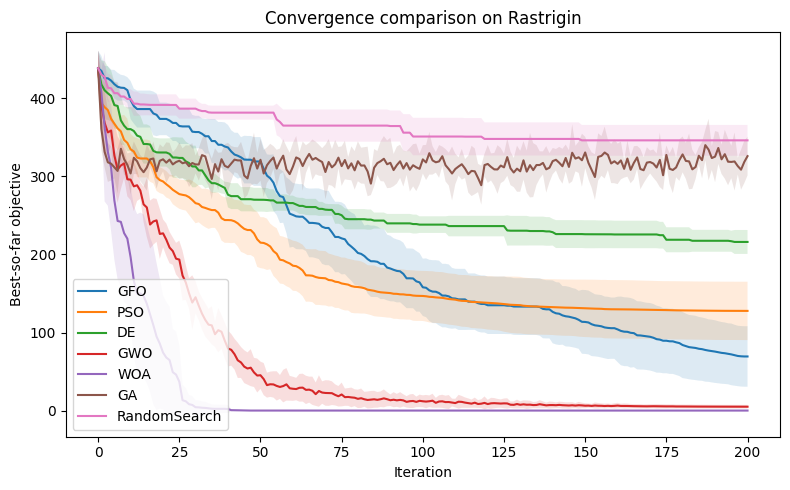

In [11]:
target_name = "Rastrigin"
func, lb_s, ub_s = BENCH_SUBSET[target_name]

infos_by_algo = {}
for algo in ALGOS:
    finals, summ, infos = repeated_runs(algo, func, lb_s, ub_s, D=30, R=8, seed0=42, iters=200, n_agents=30)
    infos_by_algo[algo] = infos

plot_convergence_curves(infos_by_algo, title=f"Convergence comparison on {target_name}")

## Step 12 — Real datasets for optimizer comparison

The paper uses 19 UCI datasets in a binary feature-selection framework.  
Since this notebook keeps **continuous GFO only**, the real-data comparison below uses optimizers to tune continuous model hyperparameters on several datasets instead of performing binary feature selection.

In [12]:
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_digits
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

CLASSIFICATION_DATASETS = {
    "Iris": load_iris(return_X_y=True),
    "Wine": load_wine(return_X_y=True),
    "BreastCancer": load_breast_cancer(return_X_y=True),
    "Digits": load_digits(return_X_y=True),
}

## Step 13 — Hyperparameter optimization objective

We optimize an RBF-SVM on each dataset.

Decision variables:
- `x[0]`: log10(C) in [-3, 3]
- `x[1]`: log10(gamma) in [-4, 1]

In [13]:
def make_svc_cv_objective(X: np.ndarray, y: np.ndarray, cv_splits: int = 3, seed: int = 42):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=seed)

    def objective(z: np.ndarray) -> float:
        log10_C = float(z[0])
        log10_gamma = float(z[1])

        C = 10.0 ** log10_C
        gamma = 10.0 ** log10_gamma

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("svc", SVC(C=C, gamma=gamma, kernel="rbf"))
        ])

        scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=None)
        return float(1.0 - np.mean(scores))

    return objective

ML_BOUNDS = np.array([-3.0, -4.0]), np.array([3.0, 1.0])

## Step 14 — Dataset comparison runner

In [14]:
def run_dataset_optimizer_once(algo_name: str, objective, lb: np.ndarray, ub: np.ndarray, seed: int, iters: int, n_agents: int):
    D = len(lb)

    if algo_name == "GFO":
        P = GFOParams(n_agents=n_agents, iters=iters, seed=seed)
        opt = GFO(objective, lb, ub, params=P, verbose=False)
        best_x, best_f, info = opt.fit()
        return best_x, best_f, info

    P = BaseOptParams(n_agents=n_agents, iters=iters)

    if algo_name == "PSO":
        return pso_opt(objective, lb, ub, params=P, seed=seed)
    elif algo_name == "DE":
        return de_opt(objective, lb, ub, params=P, seed=seed)
    elif algo_name == "GWO":
        return gwo_opt(objective, lb, ub, params=P, seed=seed)
    elif algo_name == "WOA":
        return woa_opt(objective, lb, ub, params=P, seed=seed)
    elif algo_name == "GA":
        return ga_opt(objective, lb, ub, params=P, seed=seed)
    elif algo_name == "RandomSearch":
        return random_search_opt(objective, lb, ub, params=P, seed=seed)
    else:
        raise ValueError(f"Unknown algorithm: {algo_name}")

def compare_on_real_datasets(
    datasets: Dict[str, Tuple[np.ndarray, np.ndarray]],
    algos: List[str],
    R: int = 10,
    iters: int = 60,
    n_agents: int = 15,
    seed0: int = 42,
):
    lb, ub = ML_BOUNDS
    dataset_results = {}
    best_points = {}

    for dname, (X, y) in datasets.items():
        objective = make_svc_cv_objective(X, y, cv_splits=3, seed=seed0)
        dataset_results[dname] = {}
        best_points[dname] = {}

        for algo in algos:
            vals = []
            xs = []
            for r in range(R):
                seed = seed0 + r
                best_x, best_f, _ = run_dataset_optimizer_once(
                    algo_name=algo,
                    objective=objective,
                    lb=lb,
                    ub=ub,
                    seed=seed,
                    iters=iters,
                    n_agents=n_agents
                )
                vals.append(float(best_f))
                xs.append(np.array(best_x, dtype=float))

            dataset_results[dname][algo] = np.array(vals, dtype=float)
            best_points[dname][algo] = xs

    print("=== Mean CV error across datasets (lower is better) ===")
    for dname in datasets.keys():
        print(f"\n{dname}")
        for algo in algos:
            x = dataset_results[dname][algo]
            print(f"  {algo:12s}: {np.mean(x):.4f} ± {np.std(x, ddof=1):.4f}")

    print("\n=== ANOVA across optimizers for each dataset ===")
    anova = {}
    for dname in datasets.keys():
        groups = [dataset_results[dname][algo] for algo in algos]
        stat, p = f_oneway(*groups)
        anova[dname] = {"F": float(stat), "p": float(p)}
        print(f"  {dname:12s}: F={stat:.4g}, p={p:.4g}")

    print("\n=== Wilcoxon rank-sum vs GFO ===")
    wilcox = {}
    for dname in datasets.keys():
        wilcox[dname] = {}
        ref = dataset_results[dname]["GFO"]
        for algo in algos:
            if algo == "GFO":
                continue
            _, p = ranksums(ref, dataset_results[dname][algo])
            wilcox[dname][algo] = float(p)
            print(f"  {dname:12s} vs {algo:12s}: p={p:.4g}")

    # Friedman across datasets using mean CV error per dataset
    dnames = list(datasets.keys())
    M = np.zeros((len(dnames), len(algos)))
    for i, dname in enumerate(dnames):
        for j, algo in enumerate(algos):
            M[i, j] = np.mean(dataset_results[dname][algo])

    ranks = np.vstack([rankdata(M[i, :], method="average") for i in range(M.shape[0])])
    avg_ranks = np.mean(ranks, axis=0)
    fried_stat, fried_p = friedmanchisquare(*[M[:, j] for j in range(M.shape[1])])

    print("\n=== Friedman test across datasets ===")
    print(f"  statistic={fried_stat:.4g}, p={fried_p:.4g}")

    print("\n=== Average ranks on datasets (lower is better) ===")
    for algo, rnk in sorted(zip(algos, avg_ranks), key=lambda x: x[1]):
        print(f"  {algo:12s}: {rnk:.3f}")

    rows = []
    for dname in datasets.keys():
        row = {"Dataset": dname}
        for algo in algos:
            x = dataset_results[dname][algo]
            row[algo] = f"{np.mean(x):.4f} ± {np.std(x, ddof=1):.4f}"
        rows.append(row)
    df = pd.DataFrame(rows)

    return dataset_results, best_points, anova, wilcox, {
        "friedman_stat": float(fried_stat),
        "friedman_p": float(fried_p),
        "avg_ranks": dict(zip(algos, avg_ranks))
    }, df

## Step 15 — Example run on real datasets

In [15]:
results_real, best_points_real, anova_real, wilcox_real, ranks_real, df_real = compare_on_real_datasets(
    datasets=CLASSIFICATION_DATASETS,
    algos=ALGOS,
    R=6,
    iters=40,
    n_agents=12,
    seed0=42,
)

df_real

=== Mean CV error across datasets (lower is better) ===

Iris
  GFO         : 0.0200 ± 0.0000
  PSO         : 0.0200 ± 0.0000
  DE          : 0.0222 ± 0.0034
  GWO         : 0.0244 ± 0.0034
  WOA         : 0.0222 ± 0.0034
  GA          : 0.0256 ± 0.0027
  RandomSearch: 0.0200 ± 0.0000

Wine
  GFO         : 0.0112 ± 0.0000
  PSO         : 0.0112 ± 0.0000
  DE          : 0.0112 ± 0.0000
  GWO         : 0.0121 ± 0.0023
  WOA         : 0.0112 ± 0.0001
  GA          : 0.0112 ± 0.0000
  RandomSearch: 0.0112 ± 0.0000

BreastCancer
  GFO         : 0.0205 ± 0.0009
  PSO         : 0.0208 ± 0.0007
  DE          : 0.0208 ± 0.0007
  GWO         : 0.0205 ± 0.0014
  WOA         : 0.0214 ± 0.0013
  GA          : 0.0219 ± 0.0010
  RandomSearch: 0.0214 ± 0.0007

Digits
  GFO         : 0.0130 ± 0.0005
  PSO         : 0.0133 ± 0.0005
  DE          : 0.0129 ± 0.0002
  GWO         : 0.0134 ± 0.0007
  WOA         : 0.0132 ± 0.0005
  GA          : 0.0139 ± 0.0005
  RandomSearch: 0.0135 ± 0.0003

=== ANOVA acr

,Dataset,GFO,PSO,DE,GWO,WOA,GA,RandomSearch
0,Iris,0.0200 ± 0.0000,0.0200 ± 0.0000,0.0222 ± 0.0034,0.0244 ± 0.0034,0.0222 ± 0.0034,0.0256 ± 0.0027,0.0200 ± 0.0000
1,Wine,0.0112 ± 0.0000,0.0112 ± 0.0000,0.0112 ± 0.0000,0.0121 ± 0.0023,0.0112 ± 0.0001,0.0112 ± 0.0000,0.0112 ± 0.0000
2,BreastCancer,0.0205 ± 0.0009,0.0208 ± 0.0007,0.0208 ± 0.0007,0.0205 ± 0.0014,0.0214 ± 0.0013,0.0219 ± 0.0010,0.0214 ± 0.0007
3,Digits,0.0130 ± 0.0005,0.0133 ± 0.0005,0.0129 ± 0.0002,0.0134 ± 0.0007,0.0132 ± 0.0005,0.0139 ± 0.0005,0.0135 ± 0.0003


## Step 16 — Inspect GFO hyperparameters found on each dataset

In [16]:
def summarize_best_hyperparameters(best_points_real: dict, algo_name: str = "GFO") -> pd.DataFrame:
    rows = []
    for dname, algo_dict in best_points_real.items():
        arr = np.vstack(algo_dict[algo_name])
        mean_logC = arr[:, 0].mean()
        mean_logG = arr[:, 1].mean()
        rows.append({
            "Dataset": dname,
            "mean_log10_C": mean_logC,
            "mean_log10_gamma": mean_logG,
            "mean_C": 10**mean_logC,
            "mean_gamma": 10**mean_logG,
        })
    return pd.DataFrame(rows)

summarize_best_hyperparameters(best_points_real, algo_name="GFO")

,Dataset,mean_log10_C,mean_log10_gamma,mean_C,mean_gamma
0,Iris,2.189287,-3.029835,154.627499,0.000934
1,Wine,0.791337,-2.287993,6.184963,0.005152
2,BreastCancer,1.187877,-2.050216,15.412624,0.008908
3,Digits,1.657770,-2.773055,45.474708,0.001686


# Binary GFO extension for feature selection

This notebook segment is designed to be **added after** the previous GFO notebook.

It keeps only the essential pieces needed to extend the existing continuous GFO framework with a **binary GFO** for wrapper-based feature selection.

## What this adds
- Binary transfer from continuous latent positions to binary feature masks
- Wrapper-based fitness function using k-NN classification
- A compact Binary GFO optimizer
- A small demo on a sample classification dataset

## What was intentionally removed
- Duplicate imports already present in the earlier notebook
- Repeated benchmark-function code
- Extra comparison algorithms
- Statistical postprocessing blocks
- Nonessential plotting helpers

Paste these cells **after** your existing GFO notebook, or use this file as an append-only extension.


## Step 1 - Minimal imports for the binary feature-selection extension

In [17]:
from dataclasses import dataclass
from typing import Optional
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer, load_wine, load_iris, load_digits
from sklearn.model_selection import train_test_split
from scipy.stats import ranksums, friedmanchisquare, rankdata
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

## Step 2 - Binary GFO parameters and transfer functions

These parameters follow the common wrapper-style feature-selection setting:
- `alpha` weights classification error
- `beta` weights the fraction of selected features


In [18]:
@dataclass
class ImprovedBinaryGFOParams:
    n_agents: int = 20
    iters: int = 150
    seed: int = 42
    alpha: float = 0.99
    beta: float = 0.01
    step_scale: float = 1.0
    noise_scale: float = 0.10
    mutation_rate: float = 0.03
    elite_count: int = 2
    stagnation_window: int = 15
    reinit_frac: float = 0.20
    transfer_type: str = "s"   # "s" or "v"
    n_splits: int = 5
    shuffle_cv: bool = True
    n_neighbors: int = 5

def s_transfer(X: np.ndarray) -> np.ndarray:
    P = 1.0 / (1.0 + np.exp(-X))
    return (np.random.rand(*X.shape) < P).astype(int)

def v_transfer(X: np.ndarray) -> np.ndarray:
    P = np.abs(np.tanh(X))
    B = np.random.randint(0, 2, size=X.shape)
    flip = (np.random.rand(*X.shape) < P)
    return np.where(flip, 1 - B, B).astype(int)

def binary_transfer_general(X: np.ndarray, transfer_type: str = "s") -> np.ndarray:
    if transfer_type.lower() == "s":
        return s_transfer(X)
    if transfer_type.lower() == "v":
        return v_transfer(X)
    raise ValueError("transfer_type must be 's' or 'v'")

## Step 3 - Cross-validation wrapper fitness

A continuous latent position is converted to a binary mask using a sigmoid transfer function.


In [19]:
def binary_fs_fitness_cv(
    mask: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    alpha: float = 0.99,
    beta: float = 0.01,
    n_splits: int = 5,
    shuffle_cv: bool = True,
    seed: int = 42,
    n_neighbors: int = 5,
) -> float:
    if np.sum(mask) == 0:
        return 1.0

    cols = np.where(mask == 1)[0]
    X_sub = X[:, cols]

    cv = StratifiedKFold(n_splits=n_splits, shuffle=shuffle_cv, random_state=seed)
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    scores = cross_val_score(clf, X_sub, y, cv=cv, scoring="accuracy")

    err = 1.0 - float(np.mean(scores))
    feat_ratio = len(cols) / X.shape[1]
    return alpha * err + beta * feat_ratio

## Step 4 - Wrapper-based feature-selection objective

The objective combines:
- classification error on the validation/test split
- a penalty for selecting too many features

$F = \alpha\,\mathrm{Err} + \beta\,\frac{|S|}{|D|}$


In [20]:
def binary_fs_fitness(
    mask: np.ndarray,
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    alpha: float = 0.99,
    beta: float = 0.01,
    n_neighbors: int = 5,
) -> float:
    if np.sum(mask) == 0:
        return 1.0

    cols = np.where(mask == 1)[0]

    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train[:, cols], y_train)
    y_pred = clf.predict(X_test[:, cols])

    err = 1.0 - accuracy_score(y_test, y_pred)
    feat_ratio = len(cols) / X_train.shape[1]

    return alpha * err + beta * feat_ratio

## Step 5 - Binary GFO optimizer

This is a compact binary extension of GFO:
- agents move in a continuous latent space
- latent positions are binarized before evaluation
- the best latent agent attracts the population


In [21]:
class ImprovedBinaryGFO:
    def __init__(self, X: np.ndarray, y: np.ndarray, params: Optional[ImprovedBinaryGFOParams] = None):
        self.p = ImprovedBinaryGFOParams() if params is None else params
        np.random.seed(self.p.seed)
        self.X = np.asarray(X, dtype=float)
        self.y = np.asarray(y)

    def _evaluate_population(self, X_latent: np.ndarray):
        X_bin = binary_transfer_general(X_latent, transfer_type=self.p.transfer_type)
        scores = np.zeros(X_latent.shape[0], dtype=float)
        for i in range(X_latent.shape[0]):
            scores[i] = binary_fs_fitness_cv(
                X_bin[i], self.X, self.y,
                alpha=self.p.alpha,
                beta=self.p.beta,
                n_splits=self.p.n_splits,
                shuffle_cv=self.p.shuffle_cv,
                seed=self.p.seed,
                n_neighbors=self.p.n_neighbors,
            )
        return X_bin, scores

    def _mutate_binary(self, B: np.ndarray) -> np.ndarray:
        M = (np.random.rand(*B.shape) < self.p.mutation_rate)
        return np.where(M, 1 - B, B).astype(int)

    def _latent_from_binary(self, B: np.ndarray, scale: float = 2.0) -> np.ndarray:
        return np.where(B == 1, scale, -scale).astype(float)

    def fit(self):
        n, d = self.p.n_agents, self.X.shape[1]
        X_latent = np.random.randn(n, d)

        best_mask = None
        best_latent = None
        best_score = np.inf
        history = []
        stagnation = 0

        for _ in range(self.p.iters):
            X_bin, scores = self._evaluate_population(X_latent)
            order = np.argsort(scores)

            if scores[order[0]] < best_score - 1e-12:
                best_score = float(scores[order[0]])
                best_mask = X_bin[order[0]].copy()
                best_latent = X_latent[order[0]].copy()
                stagnation = 0
            else:
                stagnation += 1

            elite_count = min(max(self.p.elite_count, 1), n)
            elite_idx = order[:elite_count]
            elite_bin = X_bin[elite_idx].copy()

            elite_bin_mut = elite_bin.copy()
            for j in range(1, elite_count):
                elite_bin_mut[j] = self._mutate_binary(elite_bin_mut[j])

            elite_latent = self._latent_from_binary(elite_bin_mut, scale=2.0)

            X_new = X_latent.copy()
            elite_idx_set = set(elite_idx.tolist())
            for i in range(n):
                if i in elite_idx_set:
                    continue
                r = np.random.rand(d)
                noise = self.p.noise_scale * np.random.randn(d)
                X_new[i] = X_latent[i] + self.p.step_scale * r * (best_latent - X_latent[i]) + noise

            X_new[elite_idx] = elite_latent

            if stagnation >= self.p.stagnation_window:
                stagnation = 0
                reinit_n = max(1, int(np.ceil(self.p.reinit_frac * n)))
                candidate_idx = [i for i in range(n) if i not in elite_idx_set]
                if len(candidate_idx) > 0:
                    chosen = np.random.choice(candidate_idx, size=min(reinit_n, len(candidate_idx)), replace=False)
                    X_new[chosen] = np.random.randn(len(chosen), d)

            X_latent = X_new
            history.append(best_score)

        return {
            "best_mask": best_mask,
            "best_score": float(best_score),
            "selected_features": int(np.sum(best_mask)),
            "history_best": np.array(history, dtype=float),
        }

## Step 6 - Comparison optimizers

These compact baseline methods operate in the same binary wrapper feature-selection setting:
- Binary random search
- Binary PSO
- Binary GA

They are intentionally lightweight so they can be appended to your previous notebook without too much duplication.


In [22]:
class BinaryRandomSearch:
    def __init__(self, X, y, n_agents=20, iters=150, seed=42, alpha=0.99, beta=0.01, n_splits=5, n_neighbors=5):
        self.X = np.asarray(X, dtype=float)
        self.y = np.asarray(y)
        self.n_agents = n_agents
        self.iters = iters
        self.seed = seed
        self.alpha = alpha
        self.beta = beta
        self.n_splits = n_splits
        self.n_neighbors = n_neighbors

    def fit(self):
        np.random.seed(self.seed)
        d = self.X.shape[1]
        best_mask = None
        best_score = np.inf
        history = []
        for _ in range(self.iters):
            pop = np.random.randint(0, 2, size=(self.n_agents, d))
            for i in range(self.n_agents):
                score = binary_fs_fitness_cv(
                    pop[i], self.X, self.y,
                    alpha=self.alpha, beta=self.beta,
                    n_splits=self.n_splits, seed=self.seed, n_neighbors=self.n_neighbors
                )
                if score < best_score:
                    best_score = float(score)
                    best_mask = pop[i].copy()
            history.append(best_score)
        return {"best_mask": best_mask, "best_score": best_score, "selected_features": int(np.sum(best_mask)), "history_best": np.array(history)}

class BinaryPSO:
    def __init__(self, X, y, n_agents=20, iters=150, seed=42, alpha=0.99, beta=0.01, n_splits=5, n_neighbors=5):
        self.X = np.asarray(X, dtype=float)
        self.y = np.asarray(y)
        self.n_agents = n_agents
        self.iters = iters
        self.seed = seed
        self.alpha = alpha
        self.beta = beta
        self.n_splits = n_splits
        self.n_neighbors = n_neighbors

    def fit(self):
        np.random.seed(self.seed)
        n, d = self.n_agents, self.X.shape[1]
        X_latent = np.random.randn(n, d)
        V = np.zeros((n, d))
        Pbest = X_latent.copy()
        Pbest_score = np.full(n, np.inf)
        Gbest = None
        Gbest_score = np.inf
        Gbest_mask = None
        history = []
        w, c1, c2 = 0.7, 1.5, 1.5

        for _ in range(self.iters):
            B = binary_transfer_general(X_latent, "s")
            for i in range(n):
                score = binary_fs_fitness_cv(
                    B[i], self.X, self.y,
                    alpha=self.alpha, beta=self.beta,
                    n_splits=self.n_splits, seed=self.seed, n_neighbors=self.n_neighbors
                )
                if score < Pbest_score[i]:
                    Pbest_score[i] = float(score)
                    Pbest[i] = X_latent[i].copy()
                if score < Gbest_score:
                    Gbest_score = float(score)
                    Gbest = X_latent[i].copy()
                    Gbest_mask = B[i].copy()

            r1 = np.random.rand(n, d)
            r2 = np.random.rand(n, d)
            V = w * V + c1 * r1 * (Pbest - X_latent) + c2 * r2 * (Gbest - X_latent)
            X_latent = X_latent + V
            history.append(Gbest_score)

        return {"best_mask": Gbest_mask, "best_score": Gbest_score, "selected_features": int(np.sum(Gbest_mask)), "history_best": np.array(history)}

class BinaryGA:
    def __init__(self, X, y, n_agents=20, iters=150, seed=42, alpha=0.99, beta=0.01, mutation_rate=0.05, n_splits=5, n_neighbors=5):
        self.X = np.asarray(X, dtype=float)
        self.y = np.asarray(y)
        self.n_agents = n_agents
        self.iters = iters
        self.seed = seed
        self.alpha = alpha
        self.beta = beta
        self.mutation_rate = mutation_rate
        self.n_splits = n_splits
        self.n_neighbors = n_neighbors

    def fit(self):
        np.random.seed(self.seed)
        n, d = self.n_agents, self.X.shape[1]
        pop = np.random.randint(0, 2, size=(n, d))
        best_mask = None
        best_score = np.inf
        history = []

        for _ in range(self.iters):
            scores = np.array([
                binary_fs_fitness_cv(ind, self.X, self.y,
                                     alpha=self.alpha, beta=self.beta,
                                     n_splits=self.n_splits, seed=self.seed, n_neighbors=self.n_neighbors)
                for ind in pop
            ], dtype=float)

            idx = np.argmin(scores)
            if scores[idx] < best_score:
                best_score = float(scores[idx])
                best_mask = pop[idx].copy()

            fitness = 1.0 / (scores + 1e-12)
            probs = fitness / np.sum(fitness)

            new_pop = []
            while len(new_pop) < n:
                p1 = pop[np.random.choice(n, p=probs)]
                p2 = pop[np.random.choice(n, p=probs)]
                cut = np.random.randint(1, d)
                c1 = np.concatenate([p1[:cut], p2[cut:]])
                c2 = np.concatenate([p2[:cut], p1[cut:]])
                m1 = np.random.rand(d) < self.mutation_rate
                m2 = np.random.rand(d) < self.mutation_rate
                c1 = np.where(m1, 1 - c1, c1)
                c2 = np.where(m2, 1 - c2, c2)
                new_pop.extend([c1, c2])

            pop = np.array(new_pop[:n], dtype=int)
            history.append(best_score)

        return {"best_mask": best_mask, "best_score": best_score, "selected_features": int(np.sum(best_mask)), "history_best": np.array(history)}

## Step 7 - Dataset loader

This uses built-in sklearn datasets so the notebook remains runnable offline.
You can later replace or extend this with UCI/OpenML datasets.


In [23]:
def _to_numeric_dataset(X, y):
    X_df = pd.DataFrame(X).copy()
    y_series = pd.Series(y).copy()

    for col in X_df.columns:
        if not pd.api.types.is_numeric_dtype(X_df[col]):
            X_df[col] = pd.Categorical(X_df[col]).codes

    X_num = X_df.replace(-1, np.nan).astype(float)
    X_num = SimpleImputer(strategy="most_frequent").fit_transform(X_num)

    if not pd.api.types.is_numeric_dtype(y_series):
        y_num = LabelEncoder().fit_transform(y_series.astype(str))
    else:
        y_num = y_series.to_numpy()

    return np.asarray(X_num, dtype=float), np.asarray(y_num)

def try_fetch_openml_dataset(name, version=1, as_frame=True):
    try:
        data = fetch_openml(name=name, version=version, as_frame=as_frame)
        X, y = _to_numeric_dataset(data.data, data.target)
        return X, y
    except Exception as e:
        print(f"Skipping {name}: {e}")
        return None

def load_feature_selection_datasets():
    datasets = {}

    data = load_breast_cancer()
    datasets["BreastCancer"] = (np.asarray(data.data, dtype=float), np.asarray(data.target))

    data = load_wine()
    datasets["Wine"] = (np.asarray(data.data, dtype=float), np.asarray(data.target))

    data = load_iris()
    datasets["Iris"] = (np.asarray(data.data, dtype=float), np.asarray(data.target))

    data = load_digits()
    datasets["Digits"] = (np.asarray(data.data, dtype=float), np.asarray(data.target))

    openml_specs = [
        ("ionosphere", 1, "Ionosphere"),
        ("sonar", 1, "Sonar"),
        ("vehicle", 1, "Vehicle"),
        ("glass", 1, "Glass"),
        ("dermatology", 1, "Dermatology"),
        ("wine-quality-red", 1, "WineQualityRed"),
        ("wine-quality-white", 1, "WineQualityWhite"),
        ("australian", 1, "Australian"),
        ("heart-statlog", 1, "HeartStatlog"),
        ("wdbc", 1, "WDBC"),
        ("blood-transfusion-service-center", 1, "BloodTransfusion"),
        ("cylinder-bands", 1, "CylinderBands"),
        ("diabetes", 1, "Diabetes"),
        ("ecoli", 1, "Ecoli"),
        ("balance-scale", 1, "BalanceScale"),
    ]

    for openml_name, version, alias in openml_specs:
        out = try_fetch_openml_dataset(openml_name, version=version, as_frame=True)
        if out is not None:
            datasets[alias] = out

    return datasets

## Step 8 - Single-run wrapper

This helper runs one optimizer on one dataset split and returns the best score and number of selected features.


In [24]:
class BinaryRandomSearch:
    def __init__(self, X, y, n_agents=20, iters=150, seed=42, alpha=0.99, beta=0.01, n_splits=5, n_neighbors=5):
        self.X = np.asarray(X, dtype=float)
        self.y = np.asarray(y)
        self.n_agents = n_agents
        self.iters = iters
        self.seed = seed
        self.alpha = alpha
        self.beta = beta
        self.n_splits = n_splits
        self.n_neighbors = n_neighbors

    def fit(self):
        np.random.seed(self.seed)
        d = self.X.shape[1]
        best_mask = None
        best_score = np.inf
        history = []
        for _ in range(self.iters):
            pop = np.random.randint(0, 2, size=(self.n_agents, d))
            for i in range(self.n_agents):
                score = binary_fs_fitness_cv(
                    pop[i], self.X, self.y,
                    alpha=self.alpha, beta=self.beta,
                    n_splits=self.n_splits, seed=self.seed, n_neighbors=self.n_neighbors
                )
                if score < best_score:
                    best_score = float(score)
                    best_mask = pop[i].copy()
            history.append(best_score)
        return {"best_mask": best_mask, "best_score": best_score, "selected_features": int(np.sum(best_mask)), "history_best": np.array(history)}

class BinaryPSO:
    def __init__(self, X, y, n_agents=20, iters=150, seed=42, alpha=0.99, beta=0.01, n_splits=5, n_neighbors=5):
        self.X = np.asarray(X, dtype=float)
        self.y = np.asarray(y)
        self.n_agents = n_agents
        self.iters = iters
        self.seed = seed
        self.alpha = alpha
        self.beta = beta
        self.n_splits = n_splits
        self.n_neighbors = n_neighbors

    def fit(self):
        np.random.seed(self.seed)
        n, d = self.n_agents, self.X.shape[1]
        X_latent = np.random.randn(n, d)
        V = np.zeros((n, d))
        Pbest = X_latent.copy()
        Pbest_score = np.full(n, np.inf)
        Gbest = None
        Gbest_score = np.inf
        Gbest_mask = None
        history = []
        w, c1, c2 = 0.7, 1.5, 1.5

        for _ in range(self.iters):
            B = binary_transfer_general(X_latent, "s")
            for i in range(n):
                score = binary_fs_fitness_cv(
                    B[i], self.X, self.y,
                    alpha=self.alpha, beta=self.beta,
                    n_splits=self.n_splits, seed=self.seed, n_neighbors=self.n_neighbors
                )
                if score < Pbest_score[i]:
                    Pbest_score[i] = float(score)
                    Pbest[i] = X_latent[i].copy()
                if score < Gbest_score:
                    Gbest_score = float(score)
                    Gbest = X_latent[i].copy()
                    Gbest_mask = B[i].copy()

            r1 = np.random.rand(n, d)
            r2 = np.random.rand(n, d)
            V = w * V + c1 * r1 * (Pbest - X_latent) + c2 * r2 * (Gbest - X_latent)
            X_latent = X_latent + V
            history.append(Gbest_score)

        return {"best_mask": Gbest_mask, "best_score": Gbest_score, "selected_features": int(np.sum(Gbest_mask)), "history_best": np.array(history)}

class BinaryGA:
    def __init__(self, X, y, n_agents=20, iters=150, seed=42, alpha=0.99, beta=0.01, mutation_rate=0.05, n_splits=5, n_neighbors=5):
        self.X = np.asarray(X, dtype=float)
        self.y = np.asarray(y)
        self.n_agents = n_agents
        self.iters = iters
        self.seed = seed
        self.alpha = alpha
        self.beta = beta
        self.mutation_rate = mutation_rate
        self.n_splits = n_splits
        self.n_neighbors = n_neighbors

    def fit(self):
        np.random.seed(self.seed)
        n, d = self.n_agents, self.X.shape[1]
        pop = np.random.randint(0, 2, size=(n, d))
        best_mask = None
        best_score = np.inf
        history = []

        for _ in range(self.iters):
            scores = np.array([
                binary_fs_fitness_cv(ind, self.X, self.y,
                                     alpha=self.alpha, beta=self.beta,
                                     n_splits=self.n_splits, seed=self.seed, n_neighbors=self.n_neighbors)
                for ind in pop
            ], dtype=float)

            idx = np.argmin(scores)
            if scores[idx] < best_score:
                best_score = float(scores[idx])
                best_mask = pop[idx].copy()

            fitness = 1.0 / (scores + 1e-12)
            probs = fitness / np.sum(fitness)

            new_pop = []
            while len(new_pop) < n:
                p1 = pop[np.random.choice(n, p=probs)]
                p2 = pop[np.random.choice(n, p=probs)]
                cut = np.random.randint(1, d)
                c1 = np.concatenate([p1[:cut], p2[cut:]])
                c2 = np.concatenate([p2[:cut], p1[cut:]])
                m1 = np.random.rand(d) < self.mutation_rate
                m2 = np.random.rand(d) < self.mutation_rate
                c1 = np.where(m1, 1 - c1, c1)
                c2 = np.where(m2, 1 - c2, c2)
                new_pop.extend([c1, c2])

            pop = np.array(new_pop[:n], dtype=int)
            history.append(best_score)

        return {"best_mask": best_mask, "best_score": best_score, "selected_features": int(np.sum(best_mask)), "history_best": np.array(history)}

## Step 9 - Repeated runs across datasets

This performs repeated independent runs to estimate mean and variability.


In [25]:
def run_binary_optimizer_once(algo_name, X, y, seed=42, n_agents=20, iters=150, alpha=0.99, beta=0.01, n_splits=5, n_neighbors=5):
    if algo_name == "BGFO":
        params = ImprovedBinaryGFOParams(
            n_agents=n_agents, iters=iters, seed=seed,
            alpha=alpha, beta=beta,
            n_splits=n_splits, n_neighbors=n_neighbors
        )
        opt = ImprovedBinaryGFO(X, y, params=params)

    elif algo_name == "BPSO":
        opt = BinaryPSO(X, y, n_agents=n_agents, iters=iters, seed=seed,
                        alpha=alpha, beta=beta, n_splits=n_splits, n_neighbors=n_neighbors)

    elif algo_name == "BGA":
        opt = BinaryGA(X, y, n_agents=n_agents, iters=iters, seed=seed,
                       alpha=alpha, beta=beta, n_splits=n_splits, n_neighbors=n_neighbors)

    elif algo_name == "BRS":
        opt = BinaryRandomSearch(X, y, n_agents=n_agents, iters=iters, seed=seed,
                                 alpha=alpha, beta=beta, n_splits=n_splits, n_neighbors=n_neighbors)
    else:
        raise ValueError(f"Unknown algorithm: {algo_name}")

    return opt.fit()

def repeated_binary_runs(datasets, algos, R=20, seed0=42, n_agents=20, iters=150, alpha=0.99, beta=0.01, n_splits=5, n_neighbors=5):
    results = {dname: {algo: {"scores": [], "features": [], "histories": []} for algo in algos} for dname in datasets}

    for dname, (X, y) in datasets.items():
        for algo in algos:
            for r in range(R):
                out = run_binary_optimizer_once(
                    algo, X, y,
                    seed=seed0 + r,
                    n_agents=n_agents,
                    iters=iters,
                    alpha=alpha,
                    beta=beta,
                    n_splits=n_splits,
                    n_neighbors=n_neighbors,
                )
                results[dname][algo]["scores"].append(float(out["best_score"]))
                results[dname][algo]["features"].append(int(out["selected_features"]))
                results[dname][algo]["histories"].append(out["history_best"])

            results[dname][algo]["scores"] = np.array(results[dname][algo]["scores"], dtype=float)
            results[dname][algo]["features"] = np.array(results[dname][algo]["features"], dtype=float)

    return results

## Step 10 - Summary tables

These tables report:
- mean ± std of the objective value
- mean ± std of the number of selected features


In [26]:
def build_score_table(results, datasets, algos):
    rows = []
    for dname in datasets:
        row = {"Dataset": dname}
        for algo in algos:
            x = np.array(results[dname][algo]["scores"], dtype=float)
            row[algo] = f"{np.mean(x):.4f} ± {np.std(x, ddof=1) if len(x) > 1 else 0.0:.4f}"
        rows.append(row)
    return pd.DataFrame(rows)

def build_feature_table(results, datasets, algos):
    rows = []
    for dname in datasets:
        row = {"Dataset": dname}
        for algo in algos:
            x = np.array(results[dname][algo]["features"], dtype=float)
            row[algo] = f"{np.mean(x):.2f} ± {np.std(x, ddof=1) if len(x) > 1 else 0.0:.2f}"
        rows.append(row)
    return pd.DataFrame(rows)

def wilcoxon_vs_bgfo(results, datasets, algos, reference="BGFO"):
    rows = []
    for dname in datasets:
        ref = np.array(results[dname][reference]["scores"], dtype=float)
        for algo in algos:
            if algo == reference:
                continue
            comp = np.array(results[dname][algo]["scores"], dtype=float)
            stat, p = ranksums(ref, comp)
            rows.append({
                "Dataset": dname,
                "Reference": reference,
                "Compared": algo,
                "Statistic": float(stat),
                "p_value": float(p),
            })
    return pd.DataFrame(rows)

def friedman_average_ranks(results, datasets, algos):
    dnames = list(datasets.keys())
    M = np.zeros((len(dnames), len(algos)), dtype=float)
    for i, dname in enumerate(dnames):
        for j, algo in enumerate(algos):
            M[i, j] = float(np.mean(results[dname][algo]["scores"]))

    ranks = np.vstack([rankdata(M[i, :], method="average") for i in range(M.shape[0])])
    avg_ranks = np.mean(ranks, axis=0)
    stat, p = friedmanchisquare(*[M[:, j] for j in range(M.shape[1])])

    rank_df = pd.DataFrame({"Algorithm": algos, "AverageRank": avg_ranks})
    rank_df = rank_df.sort_values("AverageRank", ascending=True).reset_index(drop=True)

    return {"friedman_stat": float(stat), "friedman_p": float(p), "rank_table": rank_df}

def df_to_latex(df, caption="", label=""):
    return df.to_latex(index=False, escape=False, caption=caption, label=label)

## Step 11 - Main Run

In [ ]:
datasets = load_feature_selection_datasets()

summary_rows = []
for name, (X, y) in datasets.items():
    summary_rows.append({
        "Dataset": name,
        "Instances": int(X.shape[0]),
        "Features": int(X.shape[1]),
        "Classes": int(len(np.unique(y))),
    })
dataset_summary = pd.DataFrame(summary_rows).sort_values("Dataset").reset_index(drop=True)
display(dataset_summary)

algos = ["BGFO", "BPSO", "BGA", "BRS"]

results = repeated_binary_runs(
    datasets=datasets,
    algos=algos,
    R=10,
    seed0=42,
    n_agents=20,
    iters=150,
    alpha=0.99,
    beta=0.01,
    n_splits=5,
    n_neighbors=5,
)

score_table = build_score_table(results, datasets, algos)
feature_table = build_feature_table(results, datasets, algos)
wilcox_table = wilcoxon_vs_bgfo(results, datasets, algos, reference="BGFO")
friedman_out = friedman_average_ranks(results, datasets, algos)

print("Score table:")
display(score_table)

print("\nSelected-feature table:")
display(feature_table)

print("\nWilcoxon vs BGFO:")
display(wilcox_table)

print("\nFriedman statistic:", friedman_out["friedman_stat"])
print("Friedman p-value:", friedman_out["friedman_p"])
print("\nAverage ranks:")
display(friedman_out["rank_table"])

Skipping australian: Sparse ARFF datasets cannot be loaded with as_frame=True. Use as_frame=False or as_frame='auto' instead.


,Dataset,Instances,Features,Classes
0,BalanceScale,625,4,3
1,BloodTransfusion,748,4,2
2,BreastCancer,569,30,2
3,CylinderBands,540,38,2
4,Dermatology,366,34,6
5,Diabetes,768,8,2
6,Digits,1797,64,10
7,Ecoli,336,7,8
8,Glass,214,9,6
9,HeartStatlog,270,13,2


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=score_table)

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=dataset_summary)

In [ ]:
# ============================================================
# Convergence plot for selected benchmark function
# ============================================================

selected_function = "Rastrigin"

func, lb, ub = BENCHMARKS[selected_function]
D = BENCH_DIMS.get(selected_function, 30)

infos_by_algo = {}

for algo in ALGOS:
    finals, summary, infos = repeated_runs(
        algo_name=algo,
        func=func,
        lb=lb,
        ub=ub,
        D=D,
        R=10,
        seed0=42,
        iters=200,
        n_agents=30
    )

    infos_by_algo[algo] = infos

plot_convergence_curves(
    infos_by_algo,
    title=f"Convergence behavior on {selected_function}",
    ylabel="Best-so-far objective",
    logy=False
)

In [ ]:
def plot_uci_boxplots(
    results,
    datasets_to_plot,
    algos=("BGFO", "BPSO", "BGA", "BRS"),
    metric_name="Classification Error"
):
    import matplotlib.pyplot as plt
    import numpy as np

    for dname in datasets_to_plot:

        data = [
            results[dname][algo]["scores"]
            for algo in algos
        ]

        plt.figure(figsize=(7, 5))

        bp = plt.boxplot(
            data,
            labels=algos,
            patch_artist=True,
            showmeans=True
        )

        # Optional styling
        colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)

        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.5)

        plt.ylabel(metric_name)
        plt.title(f"Performance distribution on {dname}")

        plt.grid(True, linestyle="--", alpha=0.3)

        plt.tight_layout()
        plt.show()


# Representative datasets
datasets_to_plot = [
    "Sonar",
    "Ionosphere",
    "WDBC",
    "HeartStatlog"
]

plot_uci_boxplots(
    results,
    datasets_to_plot=datasets_to_plot,
    algos=("BGFO", "BPSO", "BGA", "BRS"),
    metric_name="Classification Error"
)